<a href="https://colab.research.google.com/github/diogenesjusto/FIAP/blob/master/MBAIA/17DTSR/17DTSR_Aula3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/master/SHIFT/Data/pib.csv')

In [ ]:
df

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi3,PIBi4,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70
3,4,abr/04,106.77,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,103.09,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,102.05,103.09,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.92
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,149.51,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,144.42,149.51,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49


<Axes: >

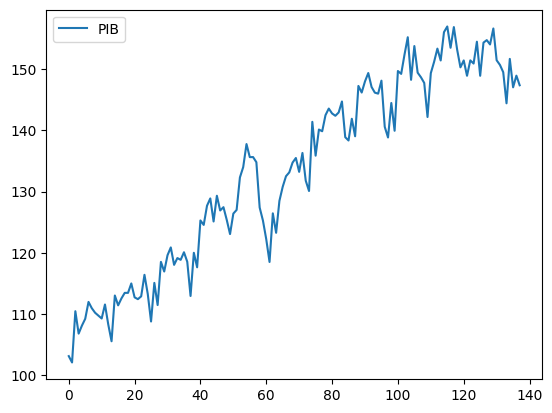

In [ ]:
# Análise Exploratória
df.plot(y='PIB')

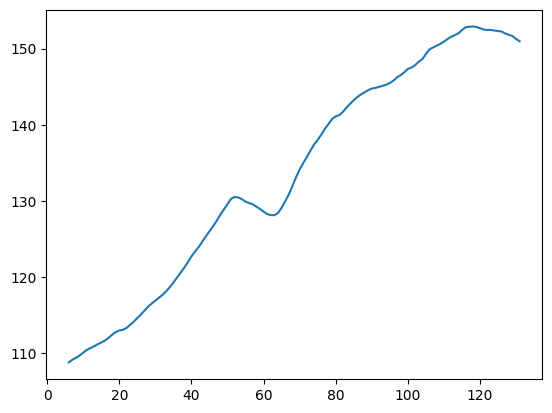

In [ ]:
# Decomposição de uma série temporal
df_seasonal = seasonal_decompose(df['PIB'], period=12)
plt.plot(df_seasonal.trend)

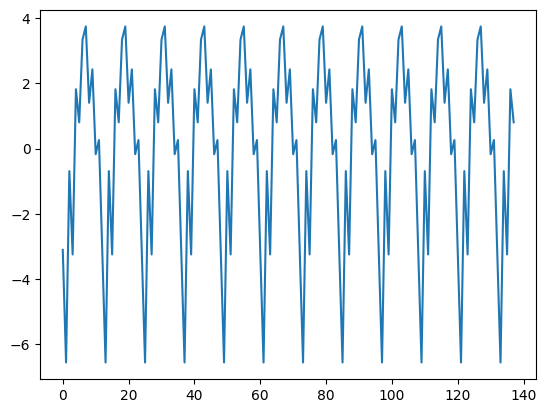

In [ ]:
plt.plot(df_seasonal.seasonal)

In [ ]:
# Construção das variáveis Dummies, uma variável dummy para cada categoria "mês" - ou seja, é uma dummy de sazonalidade mensal
pd.get_dummies(df['ANO_MES'].str[:3])

,abr,ago,dez,fev,jan,jul,jun,mai,mar,nov,out,set
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,False,False
3,True,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
133,False,False,False,True,False,False,False,False,False,False,False,False
134,False,False,False,False,False,False,False,False,True,False,False,False
135,True,False,False,False,False,False,False,False,False,False,False,False
136,False,False,False,False,False,False,False,True,False,False,False,False


In [ ]:
# Construção de uma variável com "Lag"
df['PIB_lag1'] = df['PIB'].shift(1)

# Para múltiplos Lags
df['PIB'].shift(periods=[1,2,3])

,PIB_1,PIB_2,PIB_3
0,NaN,NaN,NaN
1,103.09,NaN,NaN
2,102.05,103.09,NaN
3,110.43,102.05,103.09
4,106.77,110.43,102.05
...,...,...,...
133,149.51,150.70,151.46
134,144.42,149.51,150.70
135,151.68,144.42,149.51
136,147.03,151.68,144.42


In [ ]:
# Separação Treino e Teste
# Dados temporais (série temporal): amostragem por janela temporal
treino = df.iloc[0:126]
teste = df.iloc[126:]

In [ ]:
# Modelo para avaliação
#X = ['PIBi1', 'PIBi2'] # Modelo Auto Regressivo de ordem 2 - utilizando Lag1 e Lag2

X = ['PIBi1', 'PIBi2', 'PIBi4', 'PIBi12'] # Modelo Auto Regressivo de maior ordem com ajuste de cauda da série (Lag12)

X_treino = treino.loc[:,X]

Y_treino = treino.iloc[:,2]

mod = LinearRegression()
mod.fit(X_treino, Y_treino)

X_teste = teste.loc[:,X]
Y_teste = teste.iloc[:,2]

Y_prev = mod.predict(X_teste)
Y_prev

mean_squared_error(Y_teste, Y_prev)

10.634576598778425